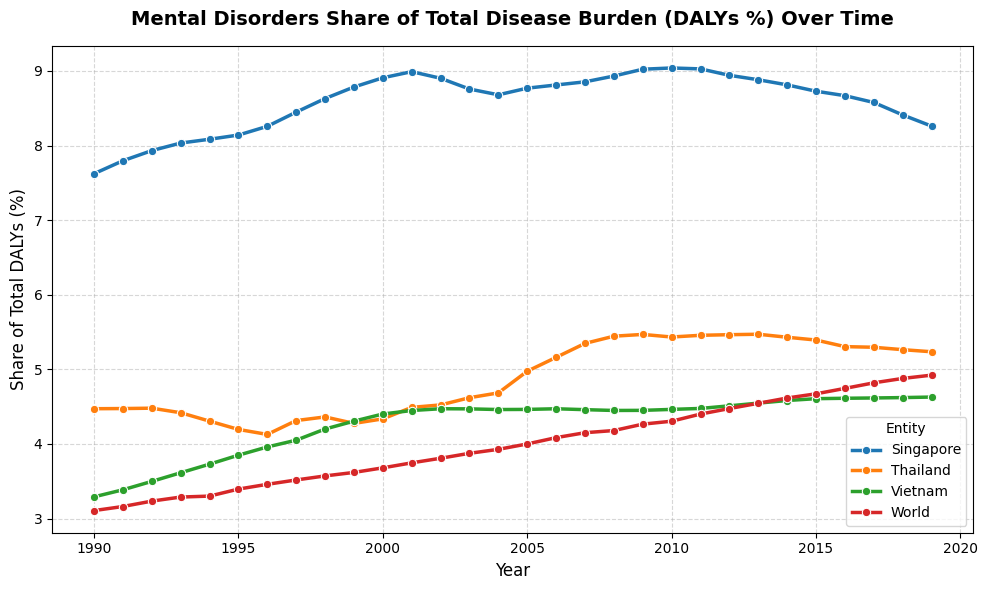


=== EPIDEMIOLOGICAL FORECAST FOR MENTAL HEALTH BURDEN IN VIETNAM ===
Projected Mental Health Burden Share for 2025: 5.08%
Projected Mental Health Burden Share for 2030: 5.28%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('mental-and-substance-use-as-share-of-disease.csv')
col_daly = df.columns[3]

countries = ['Vietnam', 'World', 'Thailand', 'Singapore']
df_filtered = df[df['Entity'].isin(countries)].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_filtered, x='Year', y=col_daly, hue='Entity', marker='o', linewidth=2.5)
plt.title('Mental Disorders Share of Total Disease Burden (DALYs %) Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Share of Total DALYs (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('mental_health_trends_vietnam.png')
plt.show()

vnm_data = df[df['Entity'] == 'Vietnam'].copy()
X_vnm = vnm_data[['Year']]
y_vnm = vnm_data[col_daly]

model = LinearRegression()
model.fit(X_vnm, y_vnm)

future_years = np.array([[2025], [2030]])
predictions = model.predict(future_years)

print("\n" + "="*60)
print("=== EPIDEMIOLOGICAL FORECAST FOR MENTAL HEALTH BURDEN IN VIETNAM ===")
print(f"Projected Mental Health Burden Share for 2025: {predictions[0]:.2f}%")
print(f"Projected Mental Health Burden Share for 2030: {predictions[1]:.2f}%")
print("="*60)